# Setup

In [1]:
from torch_harmonics.spherical_harmonics_old import SphericalHarmonics

In [8]:
L = 2
sh = SphericalHarmonics(L, 20, 20)

# Plotting Spherical Harmonics

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from torch_harmonics import plotting

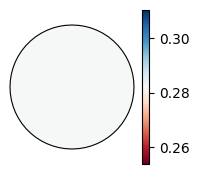

In [9]:
basis_fns = sh.Y
plotting.plot_spherical_fn(basis_fns[0,:,:].numpy(), fig=plt.figure(figsize=(2,2)))

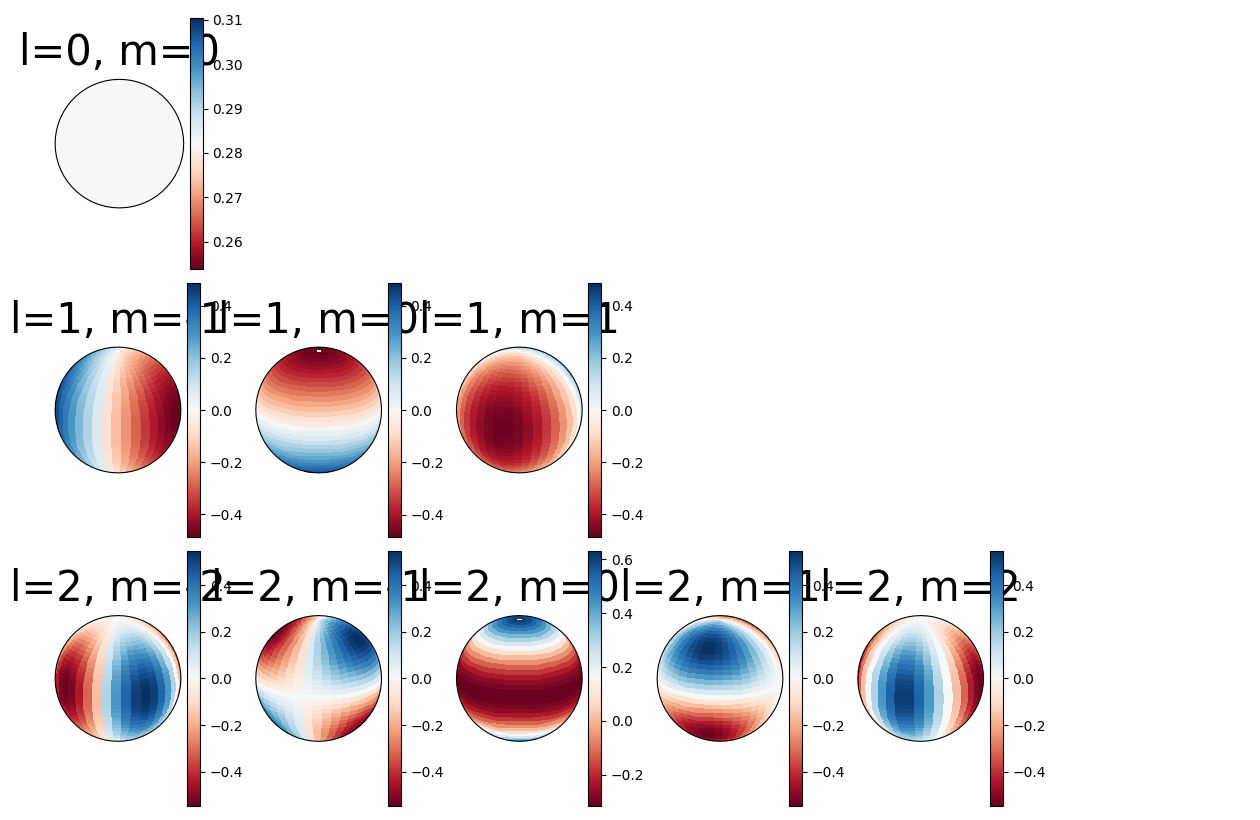

In [10]:
fig = plt.figure(layout='constrained', figsize=(12, 8))
subfigs = fig.subfigures(L+1, (L+1)*2)

irreps = np.arange(L+1)
ls = [[ls] * (2 * ls + 1) for ls in irreps]
ls = np.array([ll for sublist in ls for ll in sublist])  # 0, 1, 1, 1, 2, 2, 2, 2, 2, ...
ms = [list(range(-ls, ls + 1)) for ls in irreps]
ms = np.array([mm for sublist in ms for mm in sublist])  # 0, -1, 0, 1, -2, -1, 0, 1, 2, ...

for i in range(len(ls)):
        plotting.plot_spherical_fn(basis_fns[i,:,:], fig=subfigs[ls[i], ms[i]+ls[i]], title=f"l={ls[i]}, m={ms[i]}")

In [6]:
import torch
w = torch.rand(1,4)
print(w)
plotting.plot_spherical_fn(sh(w)[0])

tensor([[0.5554, 0.9825, 0.2792, 0.0164]])


RuntimeError: einsum(): subscript n has size 9 for operand 1 which does not broadcast with previously seen size 4

In [ ]:
import matplotlib.animation as animation

fig = plt.figure(layout='constrained', figsize=(12, 8), dpi=72)

moviewriter = animation.writers['pillow'](fps=30)
moviewriter.setup(fig, 'spherical_harmonics.gif', dpi=72)

In [ ]:
for frame in range(120):
    # compute the rotation of the sphere
    lon = -120 - 3 * frame

    if frame % 10 == 0:
        print(f"frame={frame}")
    
        plotting.plot_spherical_fn(sh(w)[0], fig=fig, central_longitude=lon)

    plt.draw()
    moviewriter.grab_frame()

moviewriter.finish()